# Commodities EDA - Advanced Data Science Project

## Import Libraries

In [1]:
# Financial data imported
import yfinance as yf

# Data manipulation tools
import pandas as pd
import pandas_datareader.data as web
import datetime

# Visualization tools
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

## YFinance Commodities Visualized

Fetching 10-year historical data from Yahoo Finance...


C:\Users\logan\AppData\Local\Temp\ipykernel_27208\816497806.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, period="10y")['Close']
[*********************100%***********************]  25 of 25 completed


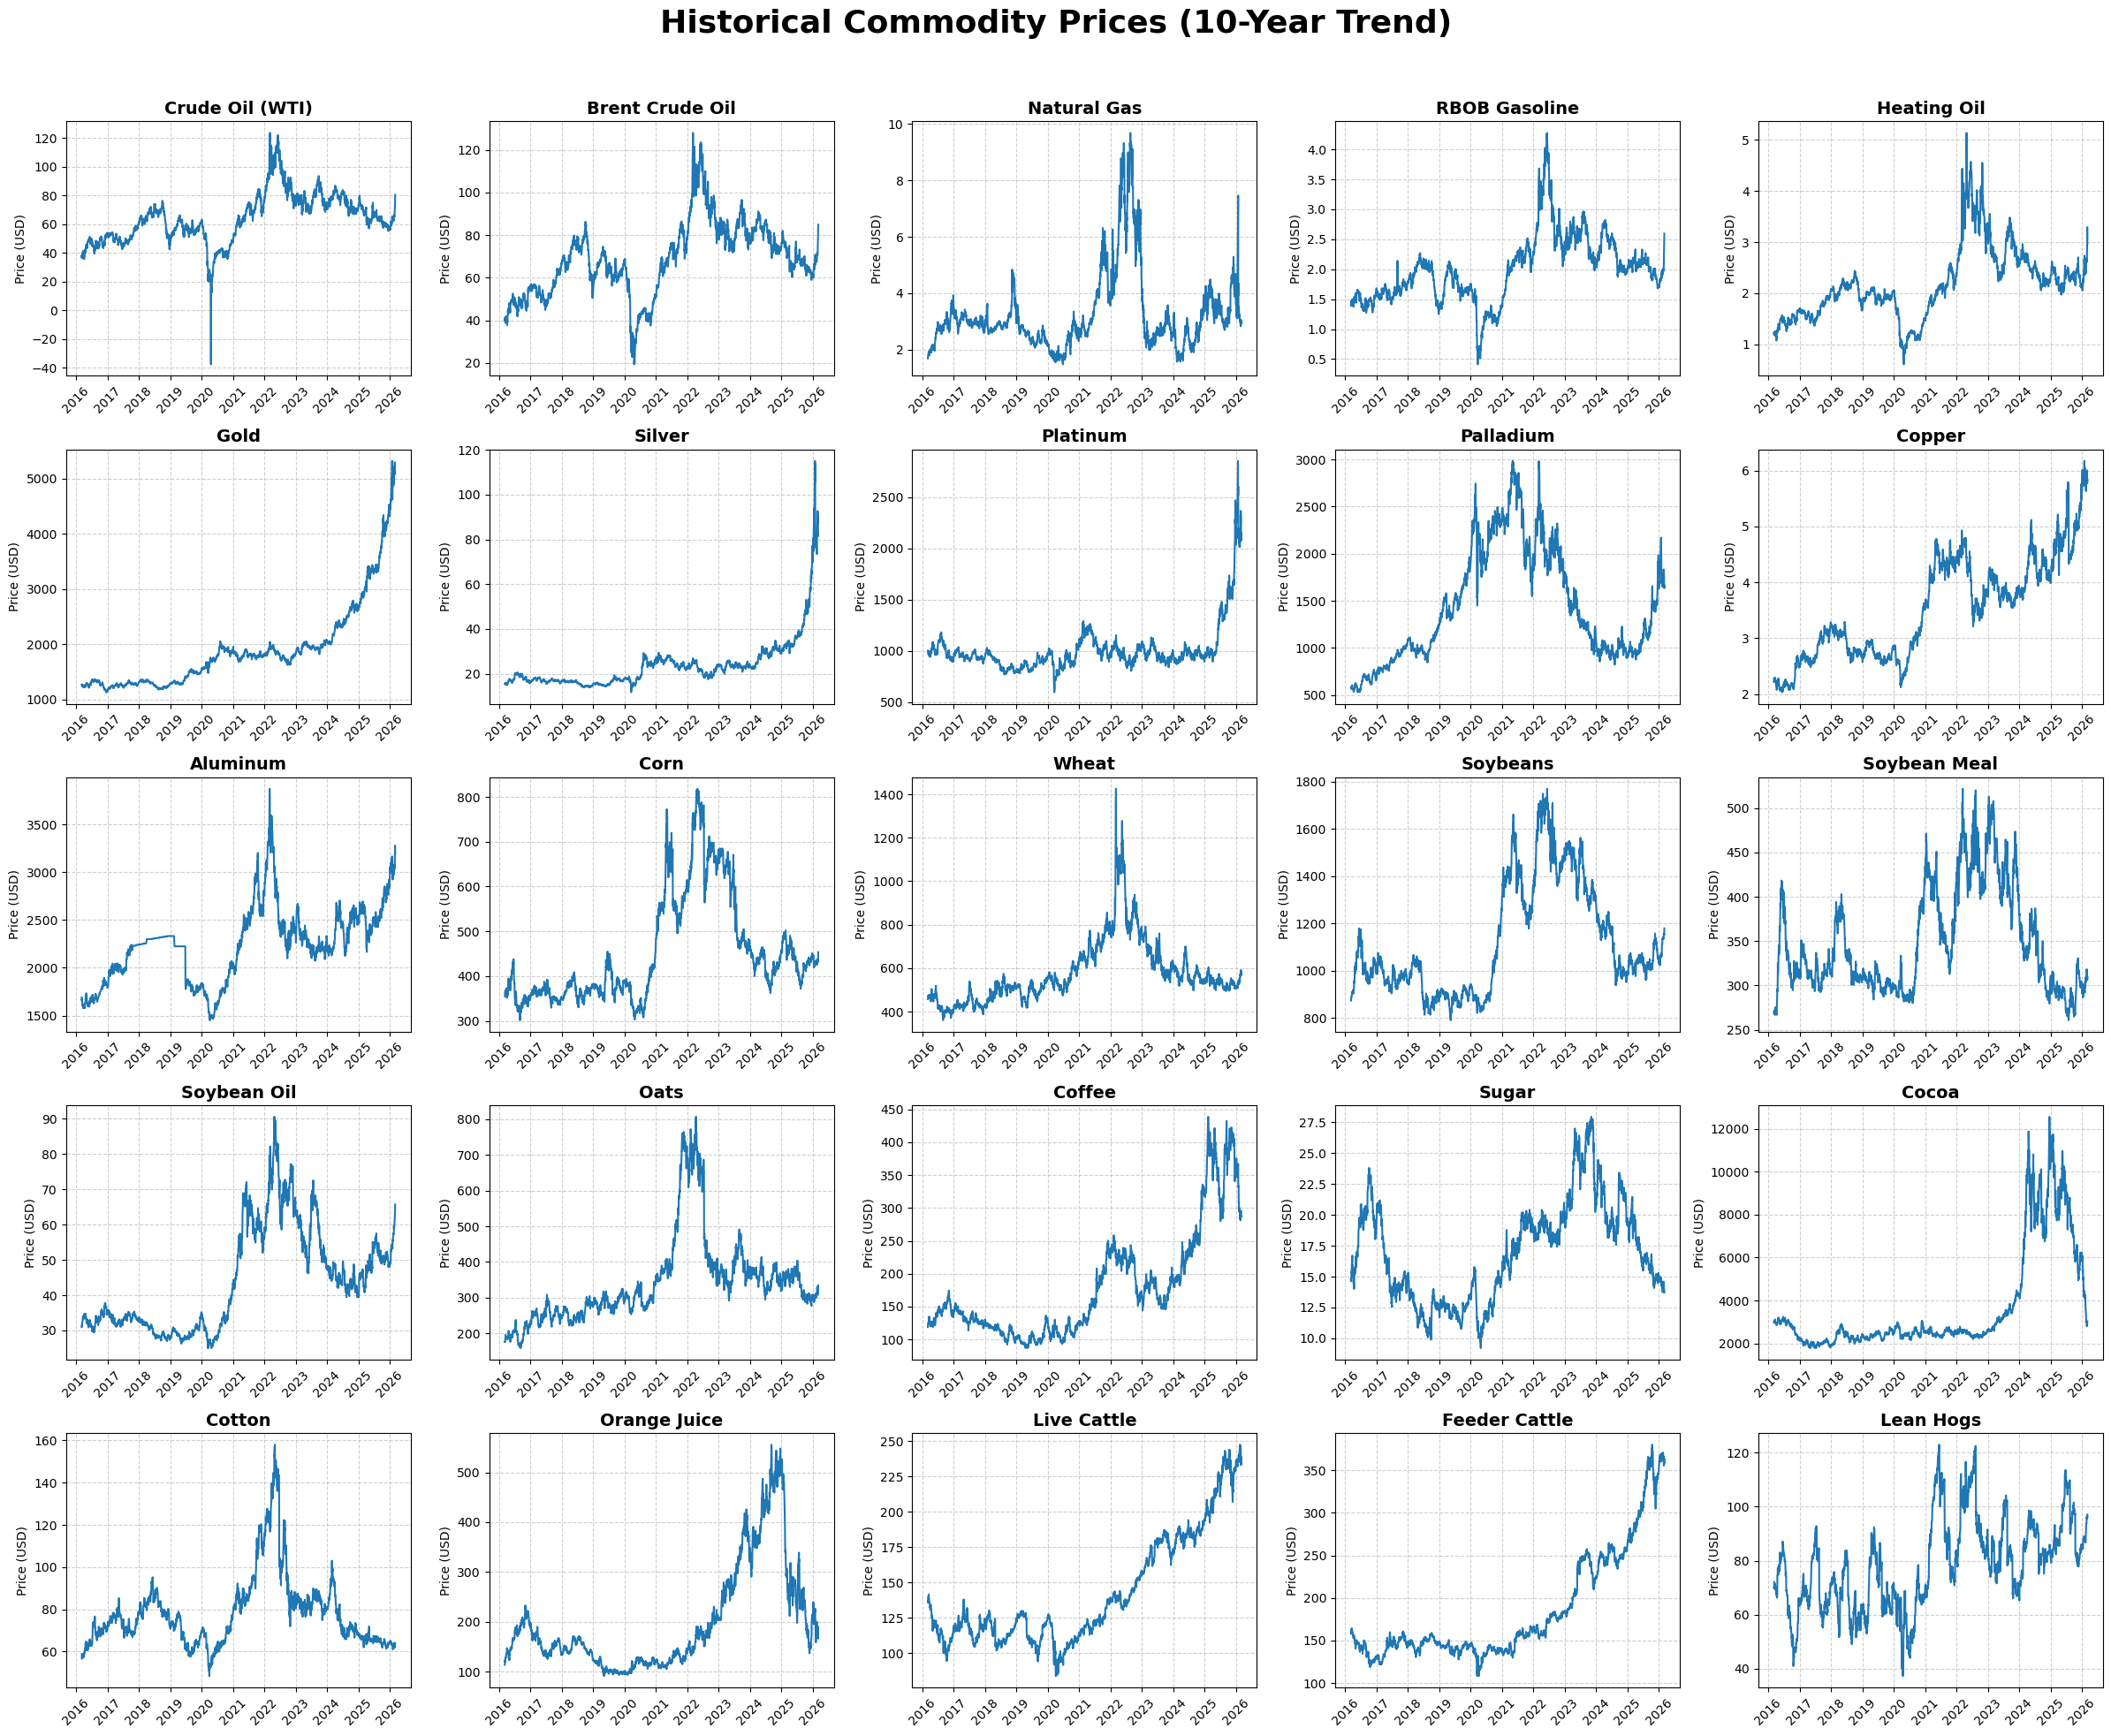

In [2]:
# 1. Define the complete dictionary of commodities
commodities = {
    'CL=F': 'Crude Oil (WTI)', 'BZ=F': 'Brent Crude Oil', 'NG=F': 'Natural Gas',
    'RB=F': 'RBOB Gasoline', 'HO=F': 'Heating Oil', 'GC=F': 'Gold',
    'SI=F': 'Silver', 'PL=F': 'Platinum', 'PA=F': 'Palladium', 'HG=F': 'Copper',
    'ALI=F': 'Aluminum', 'ZC=F': 'Corn', 'ZW=F': 'Wheat', 'ZS=F': 'Soybeans',
    'ZM=F': 'Soybean Meal', 'ZL=F': 'Soybean Oil', 'ZO=F': 'Oats',
    'KC=F': 'Coffee', 'SB=F': 'Sugar', 'CC=F': 'Cocoa', 'CT=F': 'Cotton',
    'OJ=F': 'Orange Juice', 'LE=F': 'Live Cattle', 'GF=F': 'Feeder Cattle',
    'HE=F': 'Lean Hogs'
}

tickers = list(commodities.keys())

# 2. Fetch historical data for all 25 commodities
print("Fetching 10-year historical data from Yahoo Finance...")
df = yf.download(tickers, period="10y")['Close']

# 3. Set up a 5x5 grid of subplots
# Using a very large figure size so the 25 plots have room to breathe
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(24, 20))
fig.suptitle('Historical Commodity Prices (10-Year Trend)', fontsize=26, fontweight='bold', y=0.98)

# Flatten the 5x5 matrix of axes into a 1D array to easily loop over
axes = axes.flatten()

# 4. Loop and Plot
for i, ticker in enumerate(tickers):
    ax = axes[i]
    
    # Check if the ticker data exists and drop NA values
    if ticker in df.columns:
        ticker_data = df[ticker].dropna()
        
        if not ticker_data.empty:
            ax.plot(ticker_data.index, ticker_data.values, color='tab:blue', linewidth=1.5)
            ax.set_title(commodities[ticker], fontsize=14, fontweight='bold')
            ax.set_ylabel('Price (USD)')
            ax.grid(True, linestyle='--', alpha=0.6)
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.text(0.5, 0.5, "No Data", ha='center', va='center', fontsize=12)
            ax.set_title(commodities[ticker])
    else:
        ax.text(0.5, 0.5, "No Data", ha='center', va='center', fontsize=12)
        ax.set_title(commodities[ticker])

# 5. Clean up layout and display
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Leave room for the main title
plt.show()

## Purchasing Power of Dollar | YoY Inflation Rate

C:\Users\logan\AppData\Local\Temp\ipykernel_27208\3660463400.py:32: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



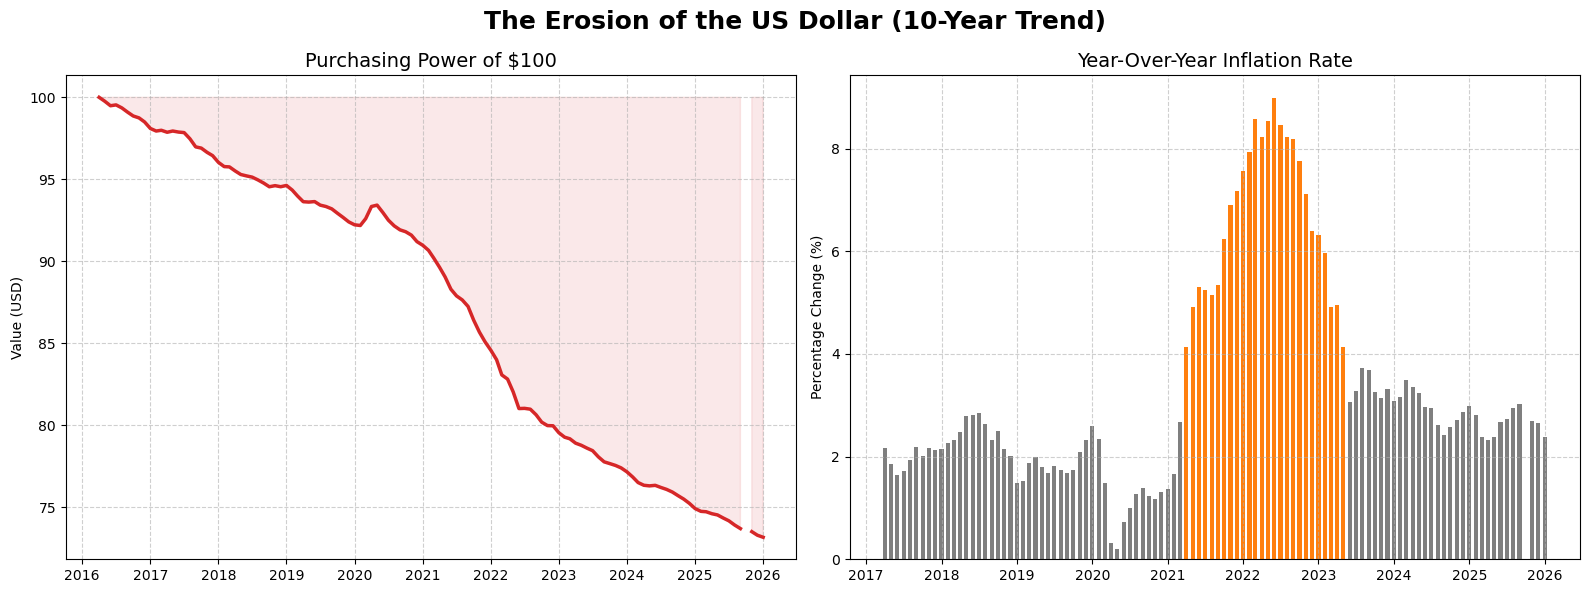

In [ ]:
"""
Important things to know about the code below:
- FRED: 
  - The "Federal Reserve Economic Data" contains large amounts of economic data
  - Here we are able to pull the CPIAUCSL 
- CPIAUCSL:
  - This is the official ticker symbol for the "Consumer Price Index for All Urban Consumers."
  - It tracks the average change over time in the prices paid by urban consumers for a market basket of consumer goods and services.
- Purchasing Power Calculation:
  - We take the base CPI (the first value in our dataset) and divide it by the current CPI to see how much $100 would be worth in today's dollars.
  - This gives us a clear picture of how much the purchasing power of the dollar has eroded over time.
- Year-Over-Year Inflation:
  - By calculating the percentage change in CPI from 12 months ago, we can see how the inflation rate has fluctuated over the past decade.
  - This is crucial for understanding the periods of high inflation and how they correlate with the decline in purchasing power.
  - NOTE: We would for example compare inflation from March 2020 to March 2021 to get the YoY change for March 2021.
- Orange Highlighting:
  - We specifically highlight periods where the YoY inflation rate exceeds 4%.
    - This is generally considered a sign of significant inflationary pressure.
"""
# Set start data and end date for 10 years of data
end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(days=10*365)

# Fetch CPI data from FRED
cpi_data = web.DataReader('CPIAUCSL', 'fred', start_date, end_date)

# Calculate Purchasing Power of $100 over time
base_cpi = cpi_data['CPIAUCSL'].iloc[0]  # CPI value at the start date
cpi_data['Purchasing_Power'] = (base_cpi / cpi_data['CPIAUCSL']) * 100  # $100's worth in today's dollars

# Calculate Year-Over-Year (YoY) Inflation Rate
cpi_data['YoY_Inflation'] = cpi_data['CPIAUCSL'].pct_change(periods=12) * 100

# Set up double visualization 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('The Erosion of the US Dollar (10-Year Trend)', fontsize=18, fontweight='bold')

# Purchasing Power Line Chart
ax1.plot(cpi_data.index, cpi_data['Purchasing_Power'], color='tab:red', linewidth=2.5)
ax1.set_title('Purchasing Power of $100', fontsize=14)
ax1.set_ylabel('Value (USD)')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.fill_between(cpi_data.index, cpi_data['Purchasing_Power'], 100, color='tab:red', alpha=0.1)

# Year-Over-Year Inflation Bar Chart
yoy_data = cpi_data.dropna()
ax2.bar(yoy_data.index, yoy_data['YoY_Inflation'], color='tab:gray', width=20)
ax2.set_title('Year-Over-Year Inflation Rate', fontsize=14)
ax2.set_ylabel('Percentage Change (%)')
ax2.grid(True, linestyle='--', alpha=0.6)

# Highlight periods of high inflation (e.g., above 4%)
high_inflation = yoy_data[yoy_data['YoY_Inflation'] > 4]
ax2.bar(high_inflation.index, high_inflation['YoY_Inflation'], color='tab:orange', width=20)

# Show plots
plt.tight_layout()
plt.show()

## Plotly Visualization of Commodities Over Time

In [ ]:
# Prepare the data
df_long = df.reset_index().melt(id_vars='Date', var_name='Ticker', value_name='Close')

# Map the tickers to their full names for better readability in the plot
df_long['Ticker Name'] = df_long['Ticker'].map(commodities).fillna(df_long['Ticker'])

# Plot
fig = px.line(
    df_long,
    x='Date',
    y='Close',
    color='Ticker Name', # Use the clear names here
    title='Commodity Closing Prices Over Time',
    labels={'Close': 'Price (USD)', 'Ticker Name': 'Commodity'},
    width=1200,
    height=800
)

# Show plot
fig.show()

# Save the plot as html file
fig.write_html("commodity_prices.html")

## Commodities Compared to Year over Year Inflation

In [ ]:
"""
Important things to know about the code below:
- GOAL: We want to create a Plotly line chart that shows the Year-Over-Year percentage change for all 25 commodities, with the US Inflation Rate as a shaded area in the background.
- Data Sources:
  - FRED: CPIAUCSL for the US Inflation Rate
  - YFincance: Commodity price data for the 25 commodities
- Normalization 
  - Just like the YoY inflation rate is calculated as the percentage change from 12 months ago, we will calculate the same for each commodity to make them comparable on the same plot.
  
"""
# Dictionary of commodities
tickers = list(commodities.keys())

# Set start data and end date for 10 years of data

end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(days=10*365)

# Fetch CPI data from FRED
cpi_data = web.DataReader('CPIAUCSL', 'fred', start_date, end_date)

# Calculate Year-Over-Year (YoY) Inflation Rate
cpi_data['YoY_Inflation'] = cpi_data['CPIAUCSL'].pct_change(periods=12) * 100
yoy_inflation = cpi_data.dropna()  # Drop the first year of NaNs created by the 12-month pct_change

# # Grab commodity data from Yahoo Finance
df = yf.download(tickers, start=start_date, end=end_date)['Close']

# Grab last price of every month's commodity data
monthly_df = df.resample('MS').last()

# Calculate the 12-month percentage change for commodities
yoy_df = monthly_df.pct_change(periods=12) * 100
yoy_df = yoy_df.dropna(how='all') # Drop first year of NaNs

# Prepare the data
df_long = yoy_df.reset_index().melt(id_vars='Date', var_name='Ticker', value_name='YoY_Change')

# Map the tickers to their full names for better readability in the plot
df_long['Commodity'] = df_long['Ticker'].map(commodities)

# Build plot
fig = px.line(
    df_long,
    x='Date',
    y='YoY_Change',
    color='Commodity',
    title='All Commodities vs. US Inflation Rate (10-Year YoY % Change)',
    labels={'YoY_Change': 'Year-Over-Year Change (%)'}
)

# Hide all lines but upcoming baseline
fig.update_traces(visible='legendonly')

# Add Inflation Rate to the background as a shaded area
inflation_trace = go.Scatter(
    x=yoy_inflation.index,
    y=yoy_inflation['YoY_Inflation'],
    name='US Inflation Rate (Baseline)',
    fill='tozeroy',  # Shades down to the 0% line
    mode='lines',
    line=dict(color='rgba(64, 64, 64, 0.9)', width=4, dash='dot'), # Dark thick dotted line
    fillcolor='rgba(128, 128, 128, 0.25)' # Semi-transparent grey fill
)
fig.add_trace(inflation_trace)

# Inflation shading stays behind the commodity lines
fig.data = (fig.data[-1],) + fig.data[:-1]

# Final touches
fig.update_layout(
    height=800,
    width=1400,
    template="plotly_white",
    legend=dict(
        title="<b>Commodities</b><br>(Double-click to isolate)", # Helpful tip for the user
        itemsizing="constant"
    )
)

# Show plot
fig.show()

# Save the plot as html file
fig.write_html("commodity_prices_vs_inflation_YoY.html")

C:\Users\logan\AppData\Local\Temp\ipykernel_27208\2747244259.py:8: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.

C:\Users\logan\AppData\Local\Temp\ipykernel_27208\2747244259.py:13: FutureWarning:

YF.download() has changed argument auto_adjust default to True



Fetching commodity data...


[*********************100%***********************]  25 of 25 completed
